In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, ks_2samp

SEED = 123
DATA_DIR = "./../data/"

df = pd.read_csv(f"{DATA_DIR}RELEXset.csv.gz")

In [4]:
df.head()

,recipe_id,stars,recipe_text
0,27208,-0.090736,"1 (4 -5 lb) beef roast, any kind 1 (1 1/4 ounc..."
1,89204,-0.194356,"4 -5 boneless chicken breasts, frozen 1 (15 1/..."
2,39087,0.224818,"2 boneless skinless chicken breast halves, cut..."
3,32204,0.123649,"1/2 cup butter, melted 1/2 cup unsweetened coc..."
4,54257,-0.072187,1 1/2 lbs ground beef (ground shoulder roast i...


## 0 -Split 

In [6]:
y = df['stars']
X = df['recipe_text']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.1, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, random_state=SEED)

## 1 - Visual Validation

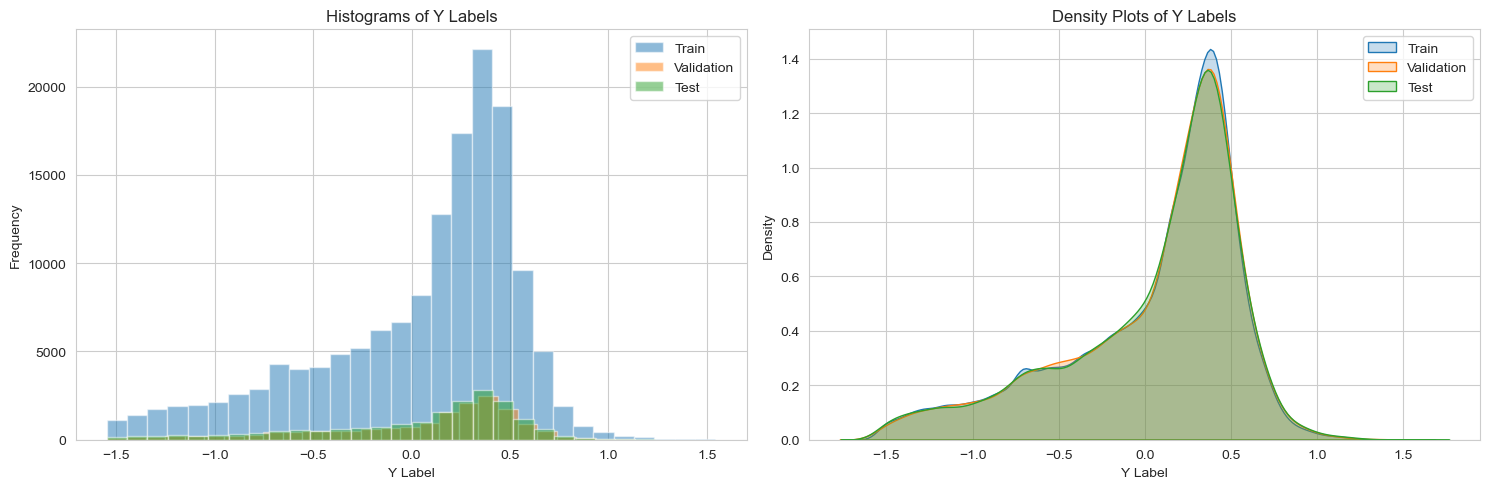

In [11]:

sns.set_style('whitegrid')
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(y_train, bins=30, alpha=0.5, label='Train')
plt.hist(y_val, bins=30, alpha=0.5, label='Validation')
plt.hist(y_test, bins=30, alpha=0.5, label='Test')
plt.xlabel('Y Label')
plt.ylabel('Frequency')
plt.title('Histograms of Y Labels')
plt.legend()

plt.subplot(1, 2, 2)
sns.kdeplot(y_train, shade=True, label='Train')
sns.kdeplot(y_val, shade=True, label='Validation')
sns.kdeplot(y_test, shade=True, label='Test')
plt.xlabel('Y Label')
plt.title('Density Plots of Y Labels')
plt.legend()

plt.tight_layout()
plt.show()


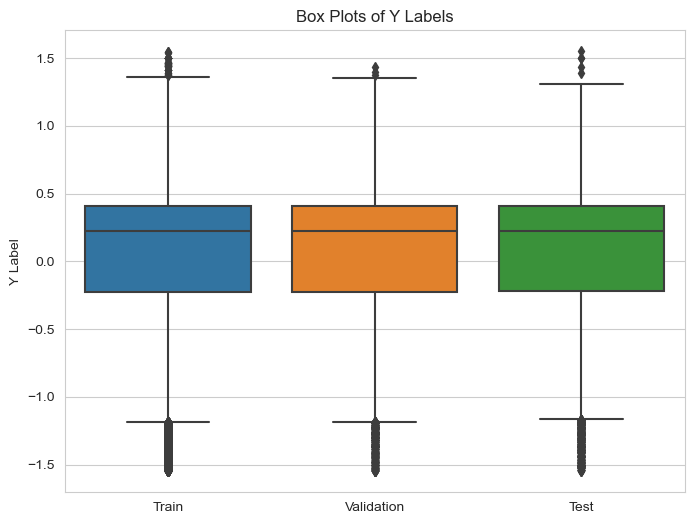

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=[y_train, y_val, y_test], orient='v')
plt.xticks([0, 1, 2], ['Train', 'Validation', 'Test'])
plt.title('Box Plots of Y Labels')
plt.ylabel('Y Label')
plt.show()


## 2 - Statistical Validation

Kolmogorov-Smirnov Test: This non-parametric test compares the cumulative distributions of two datasets to assess if they come from the same distribution. You can apply this test pairwise (train vs. validation, train vs. test, validation vs. test) to assess similarity.
Anderson-Darling Test: Similar to the Kolmogorov-Smirnov test, but more sensitive to differences in the tails of the distributions

In [14]:
data = {'Train': y_train, 'Validation': y_val, 'Test': y_test}
df = pd.DataFrame(data)

# Descriptive statistics
desc_stats = df.describe().T
print(desc_stats)


               count      mean       std       min       25%       50%  \
Train       148595.0  0.045955  0.519534 -1.549488 -0.229962  0.222342   
Validation   16511.0  0.048982  0.517358 -1.550017 -0.227951  0.226202   
Test         18346.0  0.048082  0.520087 -1.549826 -0.222556  0.222539   

                 75%       max  
Train       0.408472  1.542969  
Validation  0.409149  1.433752  
Test        0.407162  1.549826  


### Normality
Before applying parametric tests, you check if the y-labels in each set are normally distributed using the Shapiro-Wilk test. 

In [17]:
# Shapiro-Wilk Test
sw_train = shapiro(y_train)
sw_val = shapiro(y_val)
sw_test = shapiro(y_test)

print(f"Train: {sw_train}")
print(f"Validation: {sw_val}")
print(f"Test: {sw_test}")


Train: ShapiroResult(statistic=0.9053926467895508, pvalue=0.0)
Validation: ShapiroResult(statistic=0.9043054580688477, pvalue=0.0)
Test: ShapiroResult(statistic=0.9064912796020508, pvalue=0.0)


### Kolmogorov–Smirnov 

Since they are not normally distributed, we use the Kolmogorov–Smirnov test, a nonparametric test of the equality of continuous probability distributions.
Intuitively, the test provides a method to qualitatively answer the question "How likely is it that we would see two sets of samples like this if they were drawn from the same (but unknown) probability distribution?". 

In [15]:
# KS Test
ks_train_val = ks_2samp(y_train, y_val)
ks_train_test = ks_2samp(y_train, y_test)
ks_val_test = ks_2samp(y_val, y_test)

print(f"Train vs Validation: {ks_train_val}")
print(f"Train vs Test: {ks_train_test}")
print(f"Validation vs Test: {ks_val_test}")


Train vs Validation: KstestResult(statistic=0.007563027790910004, pvalue=0.361360796183817)
Train vs Test: KstestResult(statistic=0.004424662478744956, pvalue=0.9050517046495292)
Validation vs Test: KstestResult(statistic=0.007239949703213955, pvalue=0.7496113757975946)
